# 1. Files and Plotting in Python

This notebook introduces two practical skills:

1. reading and writing files;
2. creating simple plots.

## Learning objectives

By the end of this notebook, you should be able to:

- work with file paths;
- read and write text files;
- read and write CSV files;
- use `with open(...)` safely;
- create basic plots with Matplotlib;
- choose a reasonable plot for common data types;
- label plots clearly and save them to disk.

## 1. File paths

A file path tells Python where a file is located.

Python's `pathlib` module is a clean and portable way to work with paths.

In [1]:
from pathlib import Path

current_folder = Path.cwd()
print(current_folder)

data_file = current_folder / "example.txt"
print(data_file)

/Users/franci/Desktop/440MI-main/python_notebooks
/Users/franci/Desktop/440MI-main/python_notebooks/example.txt


## 2. Writing a text file

The safest pattern is to use a context manager:

```python
with open(...) as file:
    ...
```

Python closes the file automatically when the block ends.

In [ ]:
from pathlib import Path

file_path = Path("notes.txt")

with open(file_path, "w", encoding="utf-8") as file:
    file.write("Python is readable.\n")
    file.write("Files can be handled with context managers.\n")

print("File written:", file_path)

## 3. Reading a text file

In [ ]:
with open("notes.txt", "r", encoding="utf-8") as file:
    content = file.read()

print(content)

### Read line by line

In [ ]:
with open("notes.txt", "r", encoding="utf-8") as file:
    for line in file:
        print(line.strip())

## 4. Writing structured data

CSV files are commonly used to exchange tabular data.

The standard library provides the `csv` module.

In [2]:
import csv

rows = [
    ["name", "age", "score"],
    ["Anna", 31, 85],
    ["Marco", 42, 91],
    ["Elena", 28, 88],
]

with open("scores.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(rows)

## 5. Reading CSV data with the standard library

In [3]:
with open("scores.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:
        print(row)

['name', 'age', 'score']
['Anna', '31', '85']
['Marco', '42', '91']
['Elena', '28', '88']


Later we will see that **pandas** is usually more convenient for tabular datasets.

# Plotting with Matplotlib

## 6. A first plot

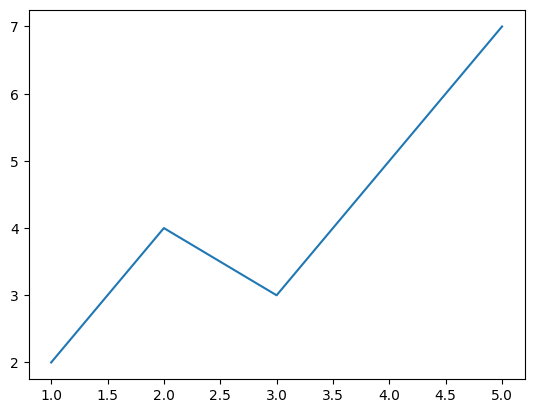

In [4]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 5, 7]

plt.plot(x, y)
plt.show()

A useful plot should normally have:

- a title;
- axis labels;
- meaningful units where appropriate.

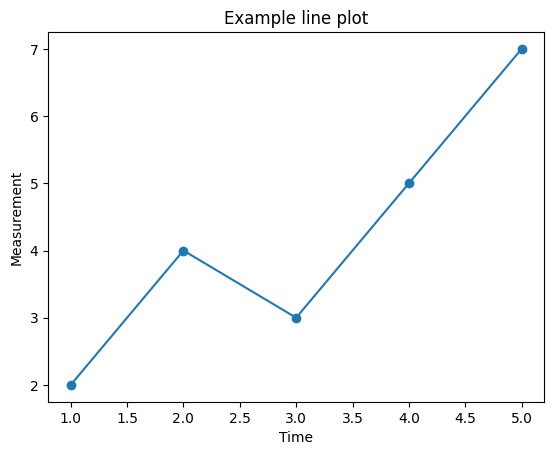

In [5]:
plt.plot(x, y, marker="o")
plt.title("Example line plot")
plt.xlabel("Time")
plt.ylabel("Measurement")
plt.show()

## 7. Scatter plots

Scatter plots are useful for studying the relationship between two numerical variables.

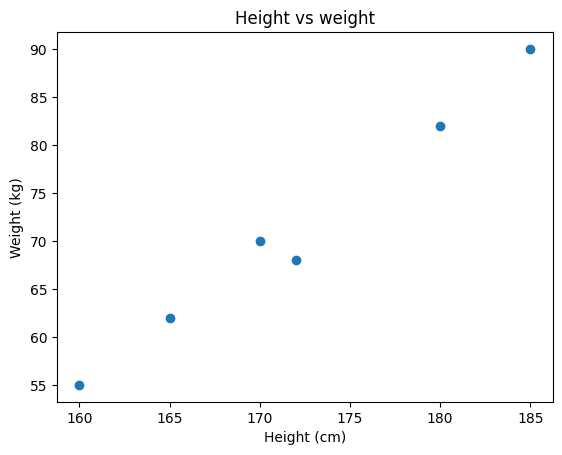

In [6]:
heights = [160, 165, 170, 172, 180, 185]
weights = [55, 62, 70, 68, 82, 90]

plt.scatter(heights, weights)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight")
plt.show()

## 8. Bar plots

Bar plots are useful for comparing categories.

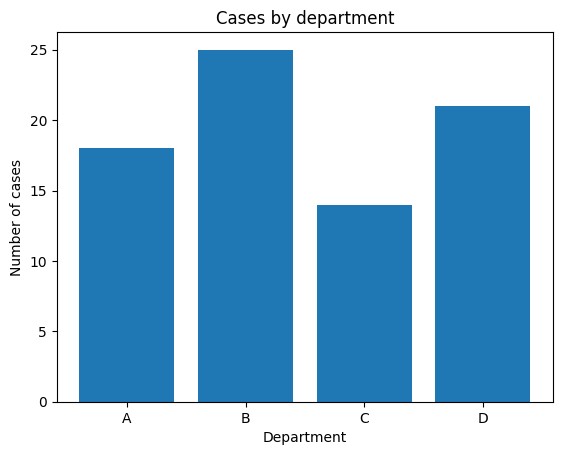

In [7]:
departments = ["A", "B", "C", "D"]
counts = [18, 25, 14, 21]

plt.bar(departments, counts)
plt.xlabel("Department")
plt.ylabel("Number of cases")
plt.title("Cases by department")
plt.show()

## 9. Histograms

Histograms show the distribution of a numerical variable.

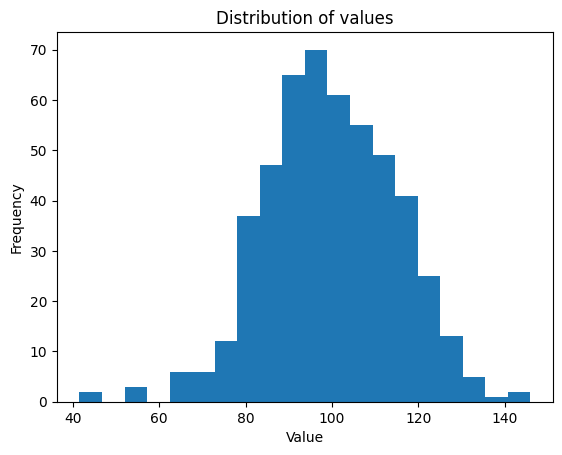

In [8]:
import numpy as np

rng = np.random.default_rng(0)
values = rng.normal(loc=100, scale=15, size=500)

plt.hist(values, bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of values")
plt.show()

## 10. Multiple series

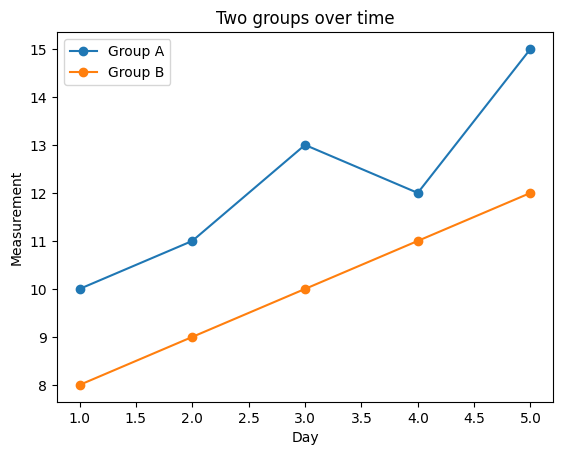

In [9]:
days = [1, 2, 3, 4, 5]
series_a = [10, 11, 13, 12, 15]
series_b = [8, 9, 10, 11, 12]

plt.plot(days, series_a, marker="o", label="Group A")
plt.plot(days, series_b, marker="o", label="Group B")
plt.xlabel("Day")
plt.ylabel("Measurement")
plt.title("Two groups over time")
plt.legend()
plt.show()

## 11. Saving a figure

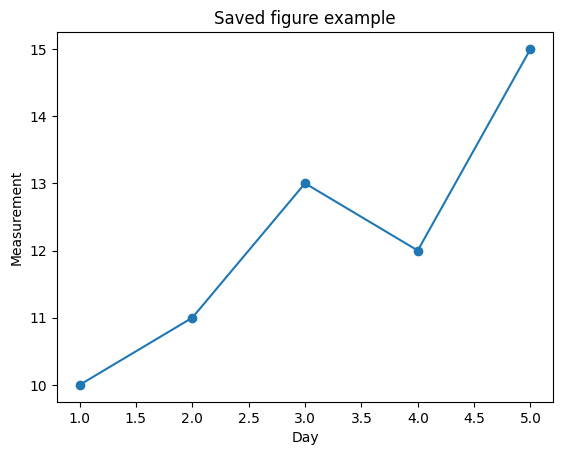

In [10]:
plt.plot(days, series_a, marker="o")
plt.title("Saved figure example")
plt.xlabel("Day")
plt.ylabel("Measurement")

plt.savefig("example_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Choosing a plot

A rough rule of thumb:

| Goal | Plot |
|---|---|
| Numerical distribution | histogram |
| Compare categories | bar plot |
| Relationship between two numerical variables | scatter plot |
| Evolution over ordered values/time | line plot |
| Distribution across groups | box plot |

# Exercise

Create a file called `temperatures.txt` containing five temperature values, one per line.

Then:

1. read the values;
2. convert them to floats;
3. plot them as a line plot;
4. add labels and a title;
5. save the figure.

In [11]:
# Write your solution here

# Possible solution

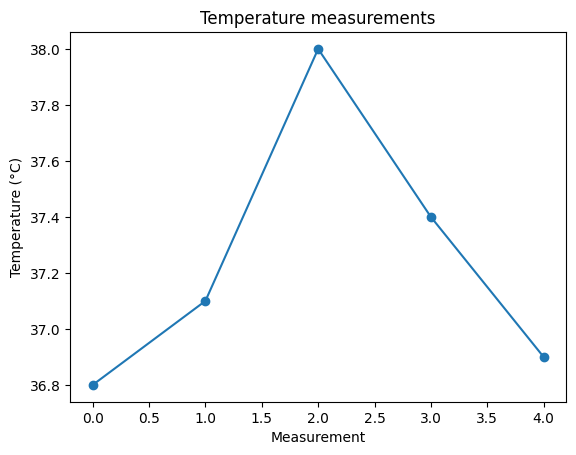

In [12]:
temperatures = [36.8, 37.1, 38.0, 37.4, 36.9]

with open("temperatures.txt", "w", encoding="utf-8") as file:
    for temperature in temperatures:
        file.write(f"{temperature}\n")

loaded_temperatures = []

with open("temperatures.txt", "r", encoding="utf-8") as file:
    for line in file:
        loaded_temperatures.append(float(line.strip()))

plt.plot(loaded_temperatures, marker="o")
plt.xlabel("Measurement")
plt.ylabel("Temperature (°C)")
plt.title("Temperature measurements")
plt.savefig("temperatures.png", dpi=150, bbox_inches="tight")
plt.show()

# Take-home messages

- `pathlib` is a convenient way to handle file paths.
- Use `with open(...)` when reading and writing files.
- CSV is a common format for structured tabular data.
- Matplotlib provides the basic plotting API in Python.
- Always label plots clearly.
- The plot type should match the question you are trying to answer.